#  Airbnb Market Analysis

##  Objective: Analyze collected Airbnb listing data to provide insights on private rooms. Combining data from multiple types: .csv, .tvs, .xlsx

# Question 1: What are the dates of the earliest and most recent reviews?

In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and explore all files
price_df = pd.read_csv("../data/airbnb_price.csv")
print(price_df.head(), "\nColumns:Rows", price_df.shape)

room_df= pd.read_excel("../data/airbnb_room_type.xlsx")
print(room_df.head(), "\nColumns:Rows", room_df.shape)

review_df = pd.read_csv("../data/airbnb_last_review.tsv", sep="\t")
print(review_df.head(), "\nColumns:Row", review_df.shape)

   listing_id        price                nbhood_full
0        2595  225 dollars         Manhattan, Midtown
1        3831   89 dollars     Brooklyn, Clinton Hill
2        5099  200 dollars     Manhattan, Murray Hill
3        5178   79 dollars  Manhattan, Hell's Kitchen
4        5238  150 dollars       Manhattan, Chinatown 
Columns:Rows (25209, 3)
   listing_id                                description        room_type
0        2595                      Skylit Midtown Castle  Entire home/apt
1        3831            Cozy Entire Floor of Brownstone  Entire home/apt
2        5099  Large Cozy 1 BR Apartment In Midtown East  Entire home/apt
3        5178            Large Furnished Room Near B'way     private room
4        5238         Cute & Cozy Lower East Side 1 bdrm  Entire home/apt 
Columns:Rows (25209, 3)
   listing_id    host_name   last_review
0        2595     Jennifer   May 21 2019
1        3831  LisaRoxanne  July 05 2019
2        5099        Chris  June 22 2019
3        5178     

In [3]:
# Cleaning data: standardizing capitalization, remove dollars and covert date type
room_df["room_type"] = room_df["room_type"].str.lower()
price_df["price"] = price_df["price"].astype(str)
price_df["price"] = price_df["price"].str.replace(" dollars","")
price_df["price"] = price_df["price"].astype(float)
review_df["last_review"] = pd.to_datetime(review_df["last_review"])

print(room_df["room_type"].head(3),
    "\n",
    review_df["last_review"].head(3), 
    "\n",
    price_df["price"].head(3))

0    entire home/apt
1    entire home/apt
2    entire home/apt
Name: room_type, dtype: object 
 0   2019-05-21
1   2019-07-05
2   2019-06-22
Name: last_review, dtype: datetime64[ns] 
 0    225.0
1     89.0
2    200.0
Name: price, dtype: float64


In [4]:
# Merge the three DataFrames into a single DataFrame  
merged_df = pd.merge(price_df,room_df, on='listing_id')
merged_df = pd.merge(merged_df,review_df, on='listing_id')
print(merged_df.head(), merged_df.shape)

   listing_id  price                nbhood_full  \
0        2595  225.0         Manhattan, Midtown   
1        3831   89.0     Brooklyn, Clinton Hill   
2        5099  200.0     Manhattan, Murray Hill   
3        5178   79.0  Manhattan, Hell's Kitchen   
4        5238  150.0       Manhattan, Chinatown   

                                 description        room_type    host_name  \
0                      Skylit Midtown Castle  entire home/apt     Jennifer   
1            Cozy Entire Floor of Brownstone  entire home/apt  LisaRoxanne   
2  Large Cozy 1 BR Apartment In Midtown East  entire home/apt        Chris   
3            Large Furnished Room Near B'way     private room     Shunichi   
4         Cute & Cozy Lower East Side 1 bdrm  entire home/apt          Ben   

  last_review  
0  2019-05-21  
1  2019-07-05  
2  2019-06-22  
3  2019-06-24  
4  2019-06-09   (25209, 7)


In [5]:
# Determine the earliest and most recent review dates
first_reviewed = merged_df["last_review"].min()
last_reviewed = merged_df["last_review"].max()
print("First review date:", first_reviewed.date())
print("Last review date:", last_reviewed.date())

First review date: 2019-01-01
Last review date: 2019-07-09


# Question 2: How many of the listings are private rooms?

In [6]:
#Finding how many listings are private rooms
nb_private_rooms = (merged_df["room_type"] == "private room").sum()
print(nb_private_rooms)

11356


# Question 3: What is the average of private rooms and all listings price?

In [7]:
#Finding the average price of listings
avg_price = merged_df["price"].mean().round(2) # type: ignore
print("The average price:", avg_price) # type: ignore

The average price: 141.78


In [8]:
#Finding the average price of private rooms
avg_private_rooms_price = merged_df.loc[merged_df["room_type"] == "private room","price"].mean().round(2)
print("The average private room price:", avg_private_rooms_price)

The average private room price: 81.64


In [9]:
#Query the table with list_id and price of private rooms
private_rooms_price_df = pd.merge(price_df,room_df, on ='listing_id', how='left')
private_room_table = private_rooms_price_df.loc[private_rooms_price_df["room_type"] == "private room"][["listing_id", "price"]]
print(private_room_table)

       listing_id  price
3            5178   79.0
6            5441   85.0
7            5803   89.0
8            6021   85.0
11           7322  140.0
...           ...    ...
25201    36390226   45.0
25204    36425863  129.0
25205    36427429   45.0
25206    36438336  235.0
25208    36455809   30.0

[11356 rows x 2 columns]


# Question 4: Create a report to client including earliest review, lastest review, number of private rooms and average price in one row.

In [10]:
#Create a Data Frame 
review_dates = pd.DataFrame({"first_reviewed": [first_reviewed],
                          "last_reviewd": [last_reviewed],
                          "nb_private_rooms": [nb_private_rooms],
                          "avg_price": [avg_price]}, index=[1])

review_dates

,first_reviewed,last_reviewd,nb_private_rooms,avg_price
1,2019-01-01,2019-07-09,11356,141.78


# Question 5: Which room type is the most expensive on avarge?

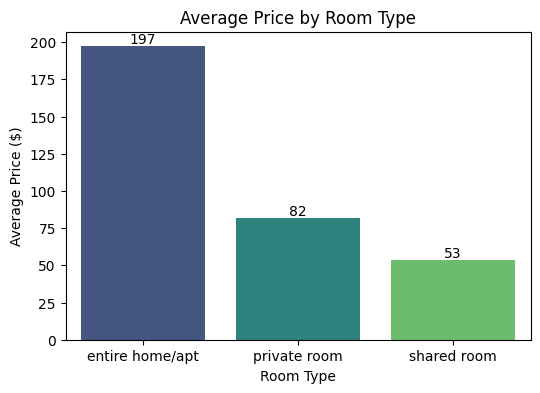

In [11]:
avg_price_by_type = merged_df.groupby("room_type")["price"].mean().round(2)
plt.figure(figsize=(6,4))
ax = sns.barplot(x=avg_price_by_type.index, y=avg_price_by_type.values, hue=avg_price_by_type.index, palette="viridis", legend=False)
plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")

#Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() /2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

# Question 6: Which room type has the most listings?

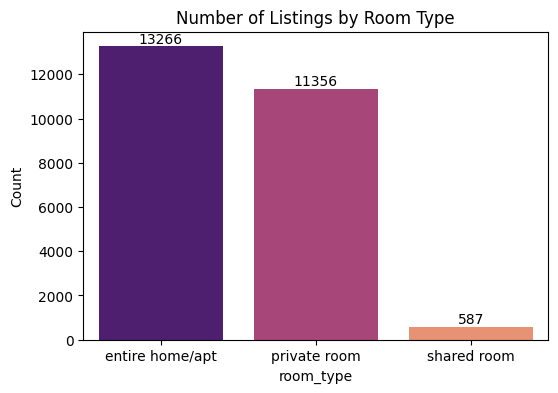

In [12]:
count_by_type = merged_df["room_type"].value_counts()
plt.figure(figsize=(6,4))

ax = sns.barplot(x=count_by_type.index, 
                   y=count_by_type.values, 
                   hue=count_by_type.index, 
                   palette="magma", 
                   legend= False)
plt.title("Number of Listings by Room Type")
plt.xlabel("room_type")
plt.ylabel("Count")

#Add vulue label
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()


In [13]:
top10_by_nbhood = (
    merged_df["nbhood_full"]
    .value_counts()
    .reset_index(name="id_count")
    .rename(columns={"index": "nbhood_full"})
)
avg_price_by_location = (
    merged_df.groupby("nbhood_full")["price"]
    .mean().round(2)
    .reset_index(name="avg_price")
    )

top10_by_nbhood = top10_by_nbhood.merge(
    avg_price_by_location,
    on="nbhood_full",
    how="left"
)
top10_by_nbhood = top10_by_nbhood.reset_index(drop=True)
top10_by_nbhood.index = top10_by_nbhood.index + 1

top10_by_nbhood.head(10)

,nbhood_full,id_count,avg_price
1,"Brooklyn, Bedford-Stuyvesant",2209,104.63
2,"Brooklyn, Williamsburg",1853,148.78
3,"Manhattan, Harlem",1435,121.75
4,"Brooklyn, Bushwick",1202,91.11
5,"Manhattan, Hell's Kitchen",1119,190.73
6,"Manhattan, East Village",866,184.28
7,"Manhattan, Upper East Side",839,173.32
8,"Manhattan, Upper West Side",775,181.14
9,"Brooklyn, Crown Heights",752,123.59
10,"Manhattan, East Harlem",672,127.17


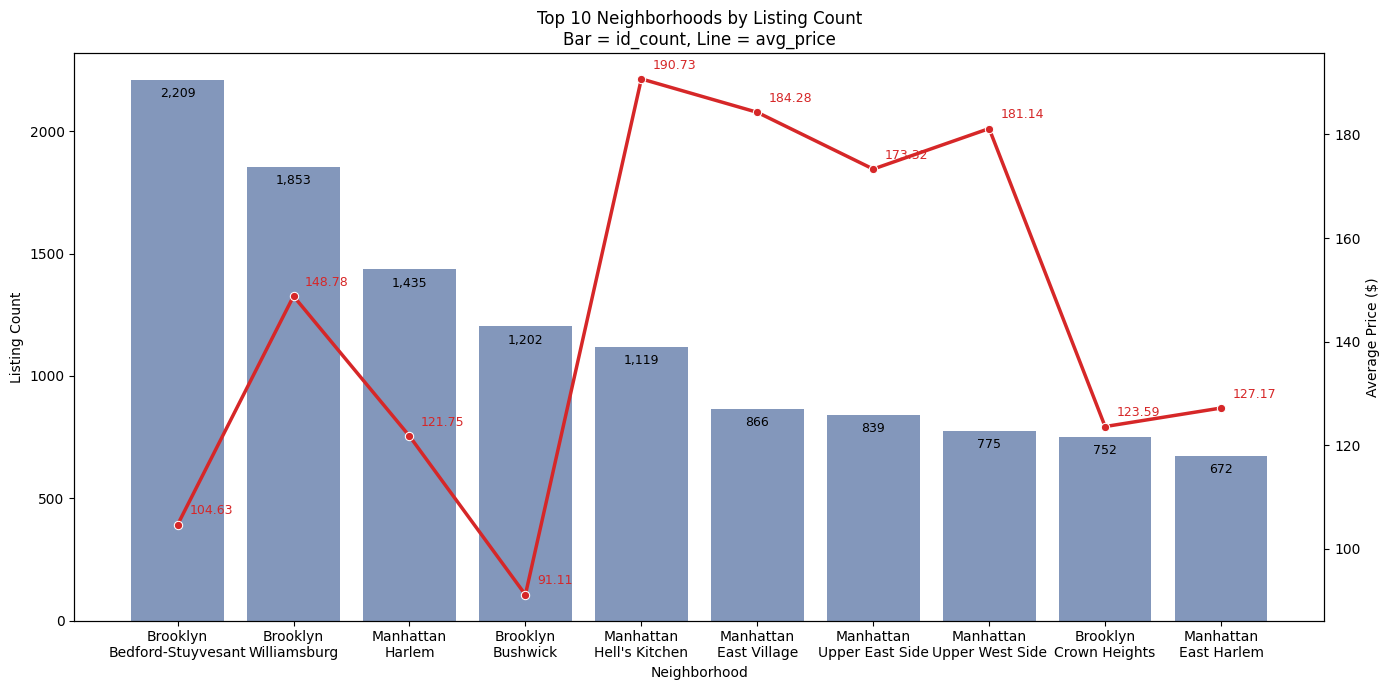

In [14]:
# Sort by id_count (descending)
df_plot = top10_by_nbhood.head(10).sort_values("id_count", ascending=False)

# Create line-broken labels
df_plot["label"] = df_plot["nbhood_full"].str.replace(", ", "\n")

plt.figure(figsize=(14,7))

# --- BAR CHART (id_count) ---
ax = sns.barplot(
    data=df_plot,
    x="label",
    y="id_count",
    color="#4C72B0",
    alpha=0.75
)

# Add id_count labels above bars
for i, v in enumerate(df_plot["id_count"]):
    ax.text(
        i,
        v - 70,
        f"{v:,}",
        ha="center",
        fontsize=9,
        color="black"
    )

# --- LINE CHART (avg_price) ---
ax2 = ax.twinx()
sns.lineplot(
    data=df_plot,
    x="label",
    y="avg_price",
    marker="o",
    linewidth=2.5,
    color="#D62728",
    ax=ax2
)

# Add avg_price labels above line points
for i in range(len(df_plot)):
    ax2.text(
        i + 0.1,    #shift slightly to the right
        df_plot["avg_price"].iloc[i] + 2,   #shift upward
        f"{df_plot['avg_price'].iloc[i]:.2f}",
        ha="left",  #align text to the right of the point
        fontsize=9,
        color="#D62728"
    )

# Smaller font for labels
plt.xticks(fontsize=8)

# Titles and labels
ax.set_title("Top 10 Neighborhoods by Listing Count\nBar = id_count, Line = avg_price")
ax.set_xlabel("Neighborhood")
ax.set_ylabel("Listing Count")
ax2.set_ylabel("Average Price ($)")

plt.tight_layout()
plt.show()



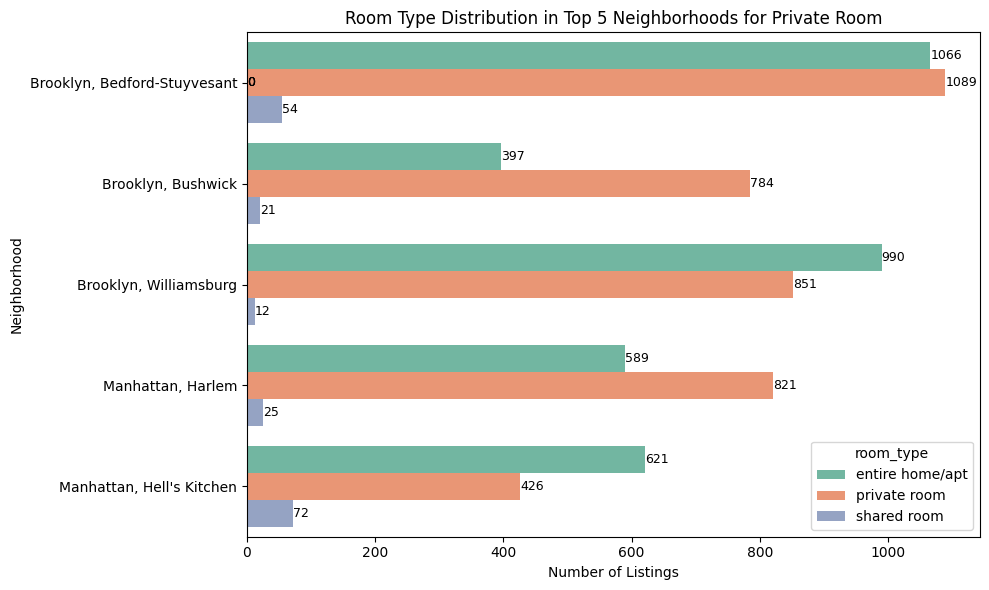

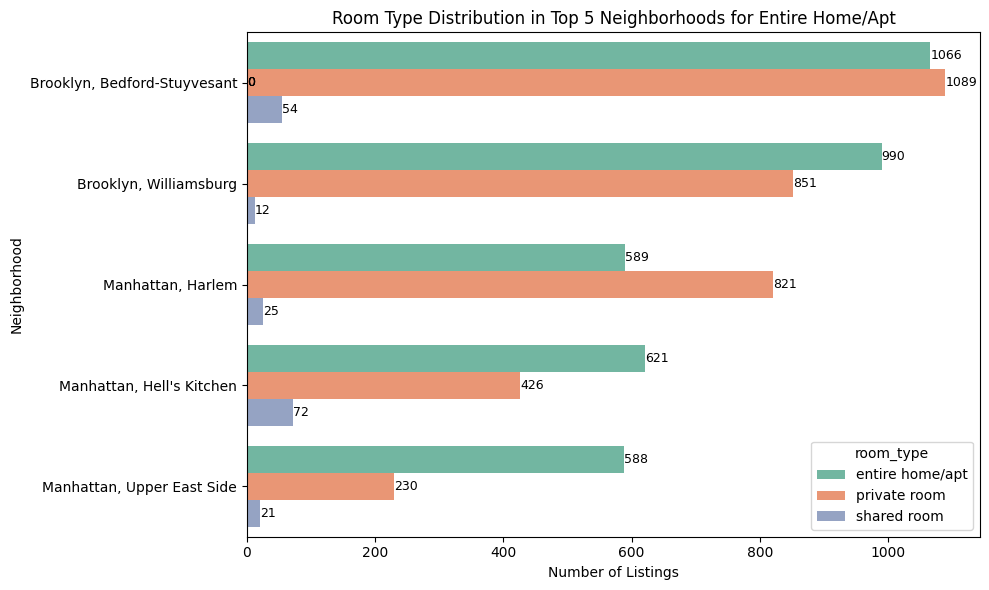

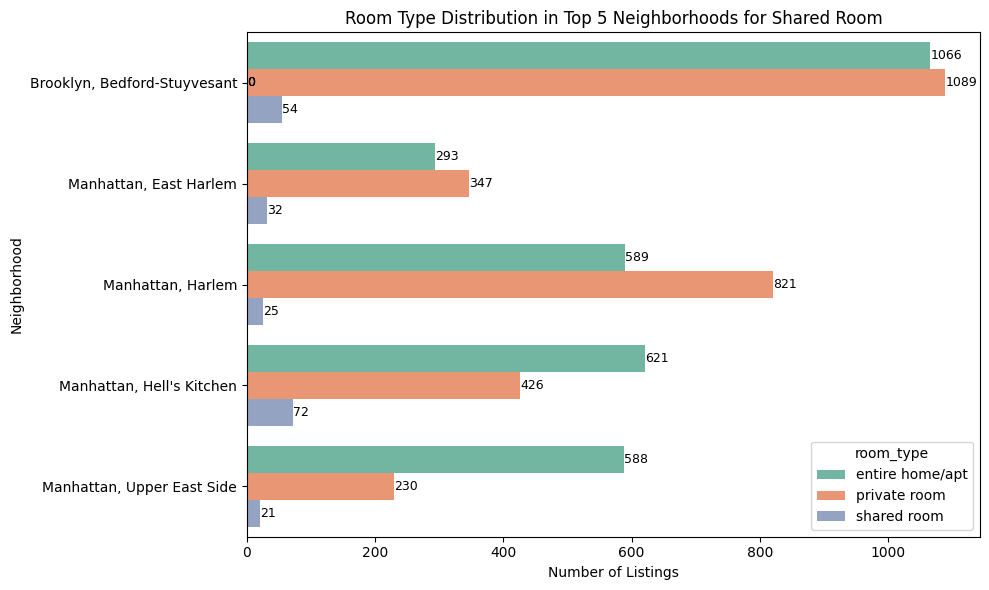

In [15]:
location_counts = (
    merged_df.groupby(["room_type", "nbhood_full"])
    .size()
    .reset_index(name="count")
)

top5_per_type = (
    location_counts.sort_values("count", ascending=False)
    .groupby("room_type")
    .head(5)
)

room_types = top5_per_type["room_type"].unique()

for rt in room_types:
        # Top 5 neighborhoods for this room type
    top5_nb = (
        top5_per_type[top5_per_type["room_type"] == rt]
        .sort_values("count", ascending=False)["nbhood_full"]
        .unique()
    )

    # Filter ALL room types for these neighborhoods
    df_plot = location_counts[location_counts["nbhood_full"].isin(top5_nb)]

    plt.figure(figsize=(10,6))

    ax = sns.barplot(
        data=df_plot,
        x="count",
        y="nbhood_full",
        hue="room_type",
        palette="Set2"
    )

    plt.title(f"Room Type Distribution in Top 5 Neighborhoods for {rt.title()}")
    plt.xlabel("Number of Listings")
    plt.ylabel("Neighborhood")

    # Add value labels
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(
            f"{int(width)}",
            (width + 0.2, p.get_y() + p.get_height()/2),
            ha="left",
            va="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

Recommendation: 
- Boost more listings of entire home/apt in the areas where Top 5 private room is.
- Shared room has a least listings, it can be considered to expand its market.
